In [ ]:
from google.colab import files
uploaded=files.upload()

Saving insurance.csv to insurance.csv


In [ ]:
import pandas as pd
df=pd.read_csv("insurance.csv")
X=df.iloc[:,: -1]
Y=df.iloc[:,6]

In [ ]:
print(X)

      age     sex     bmi  children smoker     region
0      19  female  27.900         0    yes  southwest
1      18    male  33.770         1     no  southeast
2      28    male  33.000         3     no  southeast
3      33    male  22.705         0     no  northwest
4      32    male  28.880         0     no  northwest
...   ...     ...     ...       ...    ...        ...
1333   50    male  30.970         3     no  northwest
1334   18  female  31.920         0     no  northeast
1335   18  female  36.850         0     no  southeast
1336   21  female  25.800         0     no  southwest
1337   61  female  29.070         0    yes  northwest

[1338 rows x 6 columns]


In [ ]:
print(Y)

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64


In [ ]:
print(df)

      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]


In [ ]:
df.isnull()
print(df.head(5))

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
df=pd.read_csv("insurance.csv")
le=LabelEncoder()
df['sex']=le.fit_transform(df["sex"])
df['smoker']=le.fit_transform(df["smoker"])
df['region']=le.fit_transform(df["region"])
print(df.head(6))

   age  sex     bmi  children  smoker  region      charges
0   19    0  27.900         0       1       3  16884.92400
1   18    1  33.770         1       0       2   1725.55230
2   28    1  33.000         3       0       2   4449.46200
3   33    1  22.705         0       0       1  21984.47061
4   32    1  28.880         0       0       1   3866.85520
5   31    0  25.740         0       0       2   3756.62160


In [ ]:
x=df.drop(['age','smoker','bmi'],axis=1)
y=df['charges']
print(x.head(3))
print(y.head(3))

   sex  children  region     charges
0    0         0       3  16884.9240
1    1         1       2   1725.5523
2    1         3       2   4449.4620
0    16884.9240
1     1725.5523
2     4449.4620
Name: charges, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.2, random_state=42)
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
model.summary()

AttributeError: 'LinearRegression' object has no attribute 'summary'

AttributeError: 'LinearRegression' object has no attribute 'summary'

In [ ]:
from sklearn.metrics import mean_squared_error ,r2_score
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print(mse)
print(r2)

1.604146462113555e-21
1.0


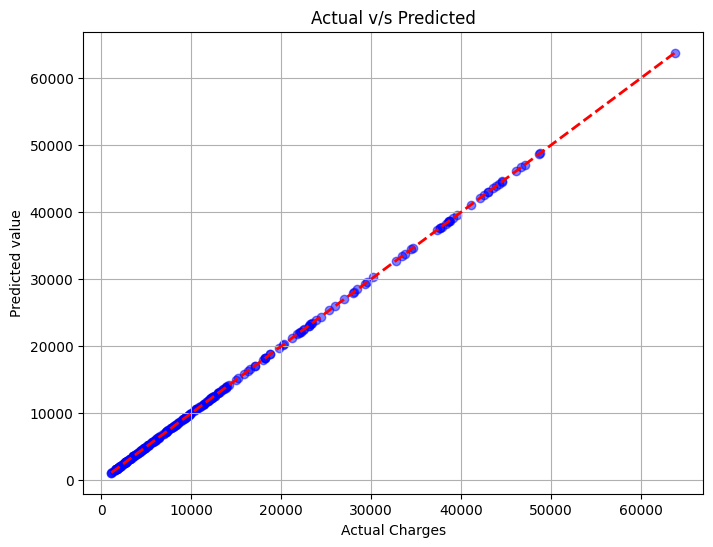

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred,color='blue',alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)

plt.xlabel('Actual Charges')
plt.ylabel('Predicted value')
plt.title("Actual v/s Predicted")
plt.grid(True)
plt.show()

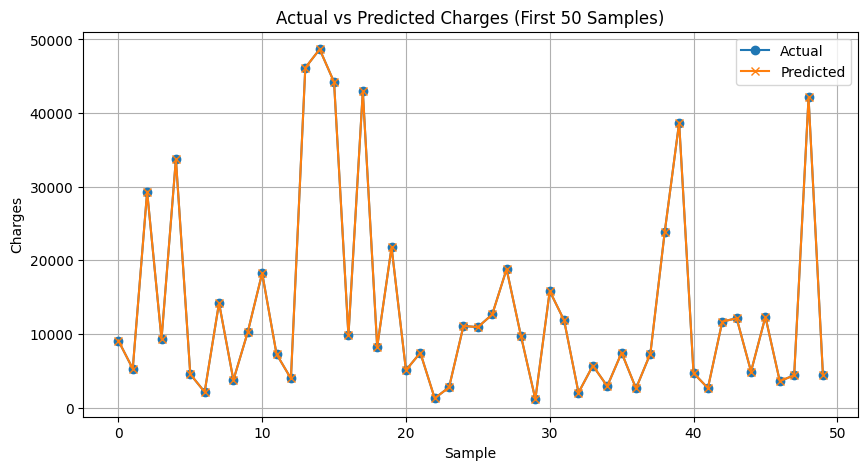

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(y_test.values[:50], label='Actual', marker='o')
plt.plot(y_pred[:50], label='Predicted', marker='x')
plt.title("Actual vs Predicted Charges (First 50 Samples)")
plt.xlabel("Sample")
plt.ylabel("Charges")
plt.legend()
plt.grid(True)
plt.show()


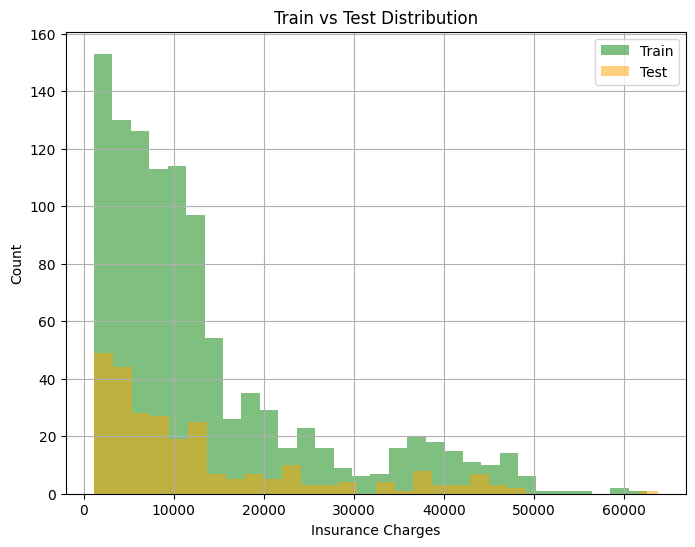

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(y_train, bins=30, alpha=0.5, label='Train', color='green')
plt.hist(y_test, bins=30, alpha=0.5, label='Test', color='orange')
plt.xlabel('Insurance Charges')
plt.ylabel('Count')
plt.title('Train vs Test Distribution')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
for actual, predicted in list(zip(y_test[:10], y_pred[:10])):
    print(f"Actual: {actual:.2f} | Predicted: {predicted:.2f}")


Actual: 9095.07 | Predicted: 9095.07
Actual: 5272.18 | Predicted: 5272.18
Actual: 29330.98 | Predicted: 29330.98
Actual: 9301.89 | Predicted: 9301.89
Actual: 33750.29 | Predicted: 33750.29
Actual: 4536.26 | Predicted: 4536.26
Actual: 2117.34 | Predicted: 2117.34
Actual: 14210.54 | Predicted: 14210.54
Actual: 3732.63 | Predicted: 3732.63
Actual: 10264.44 | Predicted: 10264.44
